In [1]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
from transformers import GPT2Model, GPT2Tokenizer, BertTokenizer, BertModel

In [3]:
gpt2 = GPT2Model.from_pretrained("gpt2")
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained("gpt2")

bert = BertModel.from_pretrained("bert-base-uncased")
tokenizer_bert = BertTokenizer.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(gpt2) 
# gpt2 has wte (word token embeddings) and wpe (word position embeddings) as its embedding layers.

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [ ]:
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [24]:
print(f"BERT MODEL has {bert.config.vocab_size:,} tokens in its vocabulary.")
print(f"BERT Tokenizer has {len(tokenizer_bert):,} tokens in its vocabulary.")
print(f"GPT-2 MODEL has {gpt2.config.vocab_size:,} tokens in its vocabulary.")
print(f"GPT-2 Tokenizer has {len(tokenizer_gpt2):,} tokens in its vocabulary.")

BERT MODEL has 30,522 tokens in its vocabulary.
BERT Tokenizer has 30,522 tokens in its vocabulary.
GPT-2 MODEL has 50,257 tokens in its vocabulary.
GPT-2 Tokenizer has 50,257 tokens in its vocabulary.


In [8]:
# Get token lengths for GPT-2
token_lengths_gpt2 = np.zeros(tokenizer_gpt2.vocab_size, dtype=int)
for idx, word in enumerate(tokenizer_gpt2.get_vocab()):
    token_lengths_gpt2[idx] = len(word)

unique_lengths_gpt2, token_counts_gpt2 = np.unique(token_lengths_gpt2, return_counts=True)

# Get token lengths for BERT
token_lengths_bert = np.zeros(tokenizer_bert.vocab_size, dtype=int)
for idx, word in enumerate(tokenizer_bert.get_vocab()):
    token_lengths_bert[idx] = len(word)
unique_lengths_bert, token_counts_bert = np.unique(token_lengths_bert, return_counts=True)

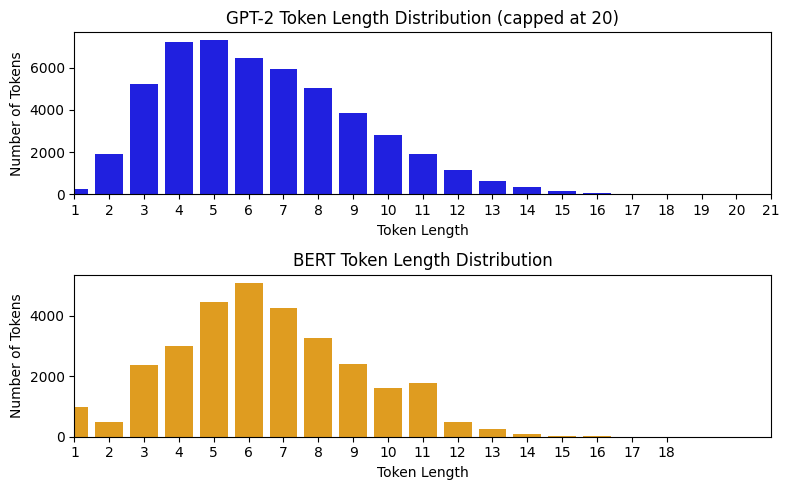

In [18]:
# Bar plot for GPT-2 and BERT lengths
fig, axes = plt.subplots(2, 1, figsize=(8, 5))

sns.barplot(x=unique_lengths_gpt2, y=token_counts_gpt2, ax=axes[0], color='blue')
axes[0].set_xlim(0, 20)
axes[0].set_title("GPT-2 Token Length Distribution (capped at 20)")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Number of Tokens")

sns.barplot(x=unique_lengths_bert, y=token_counts_bert, ax=axes[1], color='orange')
axes[1].set_xlim(0, 20)
axes[1].set_title("BERT Token Length Distribution")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Number of Tokens")

plt.tight_layout()
plt.show()

# token length distribution for GPT-2 and BERT are similar. However, it does look like BERT is shifted slightly to the right, 
# compared to GPT-2, which reflects that the BERT tokenizer has a stronger emphasis on words compare to GPT-2, which has a stronger emphasis on subwords.

In [ ]:
# get the word token embedding matrix from GPT-2 and BERT
# the word token embedding matrix is the weight matrix of the word token embedding layer, which is the first layer of the model.
# it is different from the position embedding matrix.
gpt2_wte = gpt2.wte.weight.detach().numpy()
bert_wte = bert.embeddings.word_embeddings.weight.detach().numpy()

print(f"GPT-2 word token embedding matrix shape: {gpt2_wte.shape}")
print(f"BERT word token embedding matrix shape: {bert_wte.shape}")

GPT-2 word token embedding matrix shape: (50257, 768)
BERT word token embedding matrix shape: (30522, 768)


Random token index: 1042


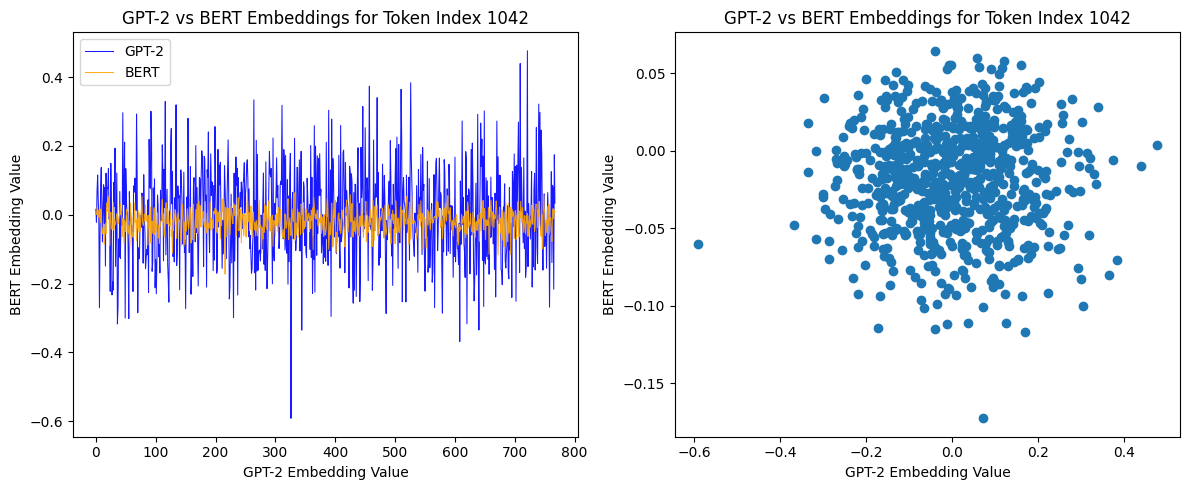

In [ ]:
# pick a random token from the GPT-2 and BERT vocabularies and get their embeddings
random_token = np.random.randint(1000, 2000)

gpt2_random_token_embedding = gpt2_wte[random_token]
bert_random_token_embedding = bert_wte[random_token]
print(f"Random token index: {random_token}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(gpt2_random_token_embedding, label="GPT-2", color='blue', linewidth=0.75, alpha=0.9)
axes[0].plot(bert_random_token_embedding, label="BERT", color='orange', linewidth=0.75, alpha=0.9)
axes[0].set_title(f"GPT-2 vs BERT Embeddings for Token Index {random_token}")
axes[0].set_xlabel("GPT-2 Embedding Value")
axes[0].set_ylabel("BERT Embedding Value")
axes[0].legend()
axes[1].scatter(gpt2_random_token_embedding, bert_random_token_embedding)
axes[1].set_title(f"GPT-2 vs BERT Embeddings for Token Index {random_token}")
axes[1].set_xlabel("GPT-2 Embedding Value")
axes[1].set_ylabel("BERT Embedding Value")
plt.tight_layout()
plt.show()

# we can see that there is clearly no relationship between the GPT-2 and BERT embeddings for the same token index. 
# This is because the two models have different vocabularies and different embedding spaces.

In [ ]:
# how about the same word?
token = "hello"
gpt2_token_id = tokenizer_gpt2.convert_tokens_to_ids(token)
bert_token_id = tokenizer_bert.convert_tokens_to_ids(token)

print(f"BERT token ID for '{token}': {bert_token_id}")
print(f"GPT-2 token ID for '{token}': {gpt2_token_id}")

# their correlation
gpt2_token_embedding = gpt2_wte[gpt2_token_id]
bert_token_embedding = bert_wte[bert_token_id]
correlation = np.corrcoef(gpt2_token_embedding, bert_token_embedding)[0, 1]
print(f"Correlation between GPT-2 and BERT embeddings for '{token}': {correlation:.4f}")

# we can see that even for the same word, the embeddings from GPT-2 and BERT are not highly correlated

BERT token ID for 'hello': 7592
GPT-2 token ID for 'hello': 31373
Correlation between GPT-2 and BERT embeddings for 'hello': 0.0693


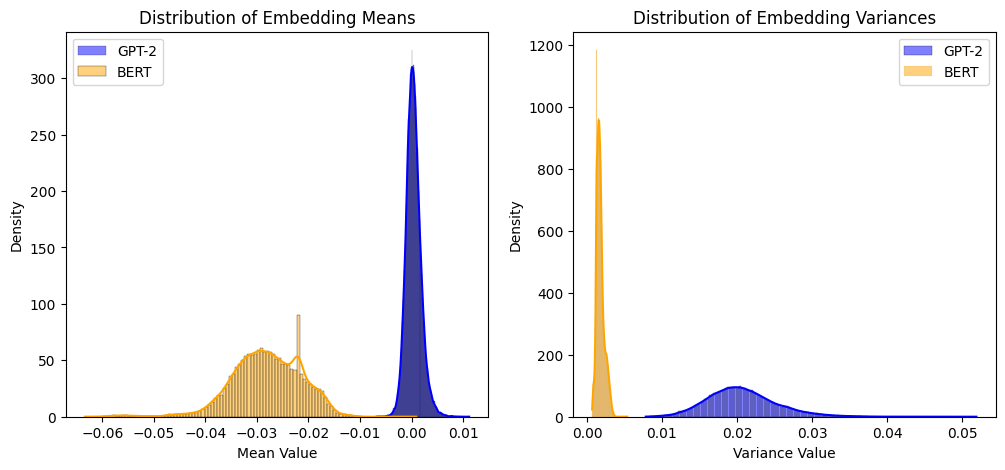

In [ ]:
# distribution of embedding variances and means for GPT-2 and BERT
gpt2_embedding_means = np.mean(gpt2_wte, axis=1)
gpt2_embedding_vars = np.var(gpt2_wte, axis=1)
bert_embedding_means = np.mean(bert_wte, axis=1)
bert_embedding_vars = np.var(bert_wte, axis=1)

# plot means on one graph and variances on another graph
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(gpt2_embedding_means, label="GPT-2", color='blue', kde=True, ax=axes[0], stat="density")
sns.histplot(bert_embedding_means, label="BERT", color='orange', kde=True, ax=axes[0], stat="density")
axes[0].set_title("Distribution of Embedding Means")
axes[0].set_xlabel("Mean Value")
axes[0].set_ylabel("Density")
axes[0].legend()
sns.histplot(gpt2_embedding_vars, label="GPT-2", color='blue', kde=True, ax=axes[1], stat="density")
sns.histplot(bert_embedding_vars, label="BERT", color='orange', kde=True, ax=axes[1], stat="density")
axes[1].set_title("Distribution of Embedding Variances")
axes[1].set_xlabel("Variance Value")
axes[1].set_ylabel("Density")
axes[1].legend()

# GPT2 embeddings have a mean around zero, so they closer to the center of the embedding space, 
# while BERT embeddings have a mean around -0.03, so they are slightly shifted to the left.

# GPT2 on the other hand, has a much wider distribution of variances, with some tokens having very high variance and others having very low variance.
# BERT has a much narrower distribution of variances, with most tokens having similar variances
# This suggests that GPT-2 embeddings are more spread out in the embedding space, while BERT embeddings are more clustered together.
# GPT2 will be less contraint when it processing one token and making a prediction for the next token because there is more variability.